# Comparaison de modèles de prévision de la demande pour la supply chain (régression)

## Introduction

Dans ce notebook, nous allons commencer à répondre au besoin du persona Sophie Martin, c'est à dire anticiper la demande afin d'éviter les ruptures de stock. Nous allons donc tester différents modèles ML pour prédire les ventes à partir des données historiques. Le but est de comparer les performances des modèles et de comprendre à quoi ils seraient le plus adaptés avant de les utiliser pour des cas plus spécifiques (juste avant un évènement, pour un produit en particulier...)

---

## Préparation des données

Dans cette première partie, nous transformons nos données pour que le modèle puisse apprendre. On a actuellement un dataset où une colonne = un jour, mais il est préférable d'avoir une ligne = une observation. 

In [1]:
import pandas as pd
import numpy as np

# Chargement des données
sales = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")
calendar = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/calendar.csv")

# Transformation des colonnes en lignes
sales = sales.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d",
    value_name="sales"
)

# Merge avec calendrier pour ajouter les dates
data = sales.merge(calendar, on="d", how="left")

---

## Contexte temporel pour le modèle

Le but de cette partie est de donner un contexte temporel au modèle comme le jour, ce qu'on vendait hier etc. On ajoute donc des colonnes à notre dataset avec ces informations.

In [2]:
# Dates
data["date"] = pd.to_datetime(data["date"])
data["dayofweek"] = data["date"].dt.dayofweek
data["month"] = data["date"].dt.month

# Tri par produits et dates
data = data.sort_values(["id", "date"])

# Lags (pour les séries temporelles)
data["lag_1"] = data.groupby("id")["sales"].shift(1) # Les ventes d'hier
data["lag_7"] = data.groupby("id")["sales"].shift(7) # Les ventes d'il y a une semaine
data["lag_28"] = data.groupby("id")["sales"].shift(28) # Les ventes du mois dernier

# Moyenne mobile des 7 derniers jours
data["rolling_mean_7"] = (data.groupby("id")["sales"].transform(lambda x: x.shift(1).rolling(7).mean()))

# Premier jour sans passé donc il faut le supprimer
data = data.dropna()

# On vérifie qu'il y a assez de données
print(data.shape)

(121960, 26)


In [3]:
# Verification qu'il n'y a pas de NaN ou valeurs manquantes
print(data.isna().sum().sort_values(ascending=False))

id                0
item_id           0
lag_28            0
lag_7             0
lag_1             0
dayofweek         0
snap_WI           0
snap_TX           0
snap_CA           0
event_type_2      0
event_name_2      0
event_type_1      0
event_name_1      0
year              0
month             0
wday              0
weekday           0
wm_yr_wk          0
date              0
sales             0
d                 0
state_id          0
store_id          0
cat_id            0
dept_id           0
rolling_mean_7    0
dtype: int64


---

## Train-Test-Split

Il serait mauvais pour le modèle de faire un simple train_test_split(X, y) parce qu'il mélangerait les dates et verrait le futur. Il faut couper dans le temps : passé = entrainement et futur = test. Ici, on entraine sur tout et on testera sur les 28 derniers jours. Les features sont les ventes précédentes (jour, mois, semaine...) et nous cherchons à prédire les ventes.

In [4]:
split_date = data["date"].max() - pd.Timedelta(days=28)
print(data["date"].min(), data["date"].max())

train = data[data["date"] <= split_date]
test = data[data["date"] > split_date]
print(data["date"].min(), data["date"].max())

features = ["dayofweek", "month", "lag_1", "lag_7", "lag_28", "rolling_mean_7"]

X_train = train[features]
y_train = train["sales"]

X_test = test[features]
y_test = test["sales"]

print(X_train.shape)
print(X_test.shape)

2011-04-24 00:00:00 2014-06-15 00:00:00
2011-04-24 00:00:00 2014-06-15 00:00:00
(91470, 6)
(30490, 6)


On a environ 75% de train et 25% de test. La plage de données est large donc c'est bon pour la suite.

---

## Modèle baseline naïf

In [6]:
# on prédit qu'on vendra exactement pareil demain que aujourd'hui
from sklearn.metrics import mean_squared_error
pred_naif = X_test["lag_1"].values
rmse_naif = np.sqrt(mean_squared_error(y_test, pred_naif))
print("RMSE Modèle naïf (lag_1) :", rmse_naif)

RMSE Modèle naïf (lag_1) : 2.7166746983873478


On va utiliser un modèle naïf qui prédit que les ventes de demain seront identiques à celles d'aujourd'hui. Il obtient un RMSE de 2.72. Ce chiffre est notre référence, si les modèles suivants sont moins bien, ça veut dire qu'ils n'apportent pas de valeurs ajoutées.

---

## Modèle 1 - Régression linéaire

On commence par un modèle très simple pour se baser sur ses résultats pour la comparaison.

RMSE :  2.3344260819222953


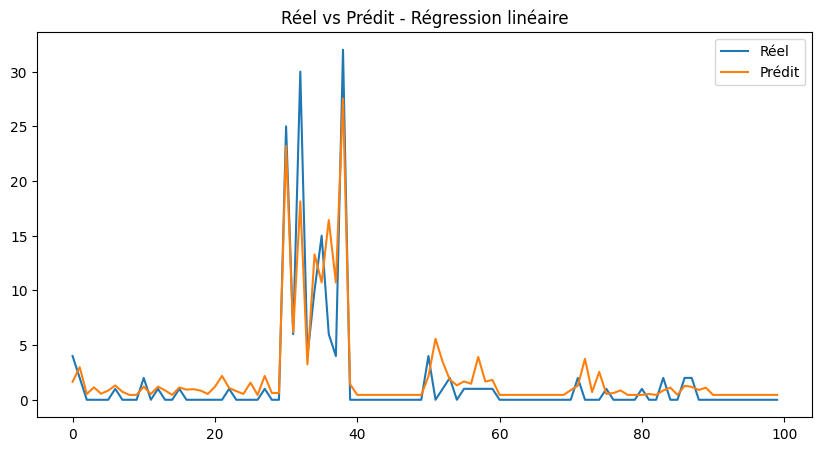

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

modele1 = LinearRegression()

modele1.fit(X_train, y_train)

pred_rl = modele1.predict(X_test)

rmse_rl = np.sqrt(mean_squared_error(y_test, pred_rl))
print("RMSE : ", rmse_rl)

# Visualisation
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Réel")
plt.plot(pred_rl[:100], label="Prédit")
plt.legend()
plt.title("Réel vs Prédit - Régression linéaire")
plt.show()

En régression linéaire, le score RMSE est plutôt bon : il suit globalement bien la tendance des ventes. Les pics et creux sont assez bien représentés même s'ils ne sont pas parfaitement corrects. Le modèle est donc plutôt efficace dans notre contexte.

---

## Modèle 2 - Random Forest

Ce modèle est normalement plus précis et devrait donc mieux capter les variations

RMSE Random Forest : 2.486900927214705


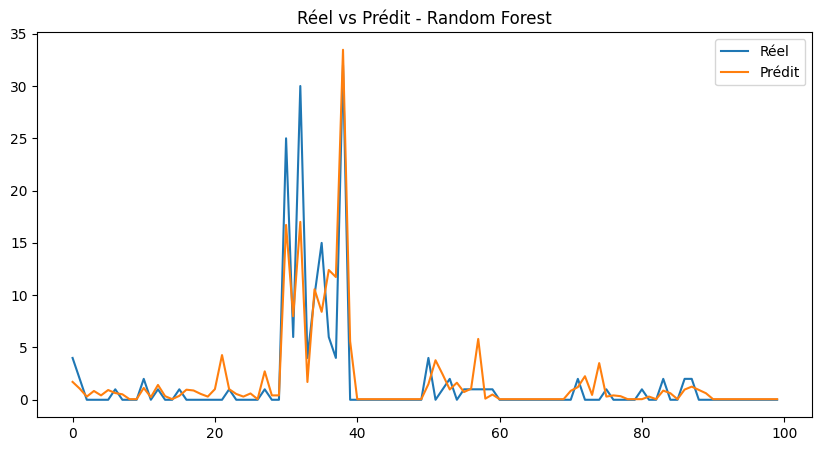

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print("RMSE Random Forest :", rmse_rf)

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Réel")
plt.plot(pred_rf[:100], label="Prédit")
plt.legend()
plt.title("Réel vs Prédit - Random Forest")
plt.show()

Le Random Forest (avec 200 arbres) arrive à capturer certains pics de demande (notamment celui en abcisse 40), mais a une performance globale légèrement plus faible que la régression linéaire.

---

### Importance des features

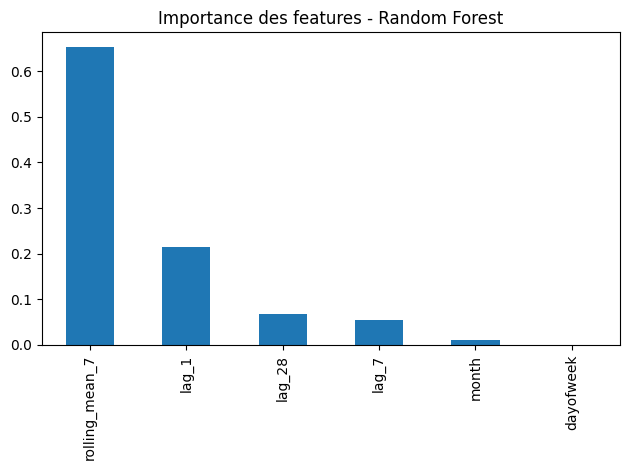

In [9]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind="bar", title="Importance des features - Random Forest")
plt.tight_layout()
plt.show()

Le graphe d'importance des features montre que rolling_mean est de loin la plus importante pour la prédiction. Cela confirme que le passé relativement récent est meilleur pour prédire les ventes futures que le passé du mois précédent par exemple.

---

## Modèle 3 - XGBoost

XGBoost est un modèle de boosting basé sur les arbres. Nous espérons donc qu'il offre de meilleures performances que les modèles pécédents.

In [10]:
import xgboost
print(xgboost.__version__)

2.0.3


RMSE XGBoost : 2.5140346452060167


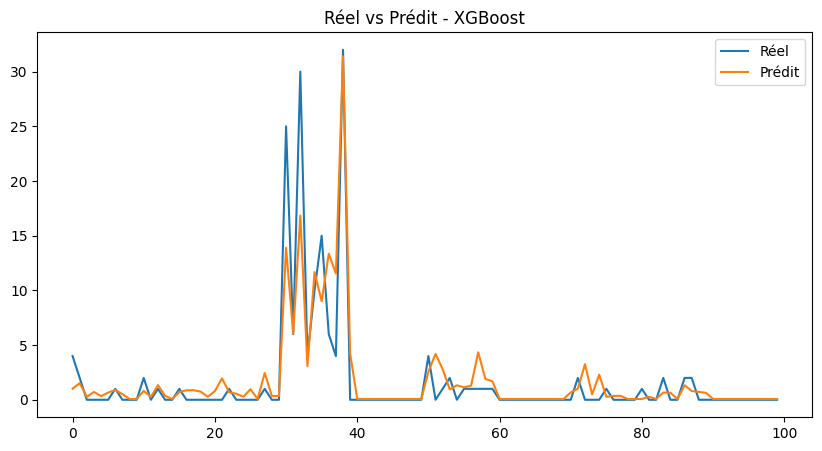

In [11]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

xgb = XGBRegressor(
    n_estimators=100,   # nombre d’arbres
    max_depth=6,        # profondeur des arbres
    random_state=42,
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print("RMSE XGBoost :", rmse_xgb)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Réel")
plt.plot(pred_xgb[:100], label="Prédit")
plt.legend()
plt.title("Réel vs Prédit - XGBoost")
plt.show()

XGBoost capture certaines variations mais n'améliore pas les performances globales.

---

## Modèle 4 - MLP

RMSE MLP : 2.553039567556169


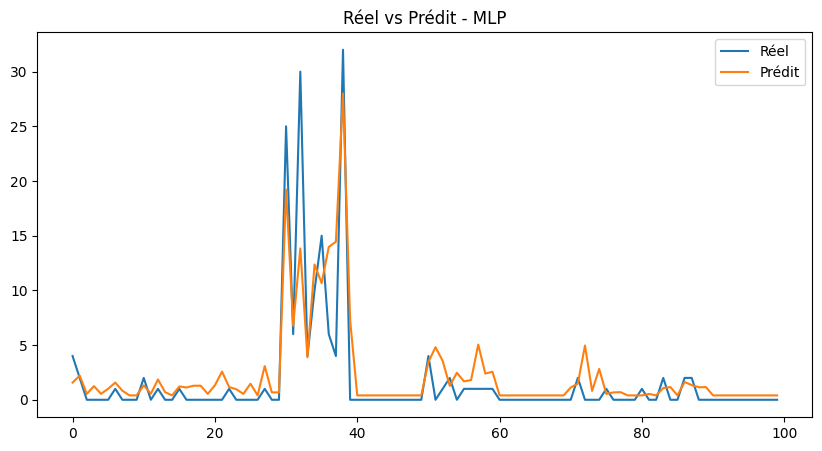

In [22]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

mlp = MLPRegressor(
    hidden_layer_sizes=(50, 50),  # 2 couches de 50 neurones
    activation='relu',
    max_iter=200,
    random_state=42
)

mlp.fit(X_train, y_train)

pred_mlp = mlp.predict(X_test)

rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))
print("RMSE MLP :", rmse_mlp)

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Réel")
plt.plot(pred_mlp[:100], label="Prédit")
plt.legend()
plt.title("Réel vs Prédit - MLP")
plt.show()

Le MLP obtient des performances moins bonnes que les précédents modèles. Cela peut s'expliquer par la nature des données qui sont trop intermittentes et ont beaucoup de bruit. Le réseau de neuronnes n'arrive donc pas à identifier des patterns stables et fait des prédictions peu précises.

---

## Conclusion

La comparaison des modèles montre que les approches les plus complexes (Random Forest, XGBoost et MLP) n'améliorent pas les performances par rapport à un modèle simple comme la régression linéaire. Cependant, tous les modèles dépassent le modèle naïf, donc c'est rassurant de voir qu'ils servent quand même à quelque chose.

Dans notre contexte avec des données intermittentes, des pics rares et difficiles à anticiper et une forte variabilité selon les produits, les modèles ont du mal à identifier des patterns et généraliser. 

### Tableau récapitulatif final

In [18]:
resultats = pd.DataFrame({
    "Modèle": ["Naïf (baseline)", "Régression linéaire", "Random Forest", "XGBoost", "MLP"],
    "RMSE": [rmse_naif, rmse_rl, rmse_rf, rmse_xgb, rmse_mlp]  # adapte les noms de variables
})
resultats = resultats.sort_values("RMSE")
print(resultats.to_string(index=False))

             Modèle     RMSE
Régression linéaire 2.334426
      Random Forest 2.486901
            XGBoost 2.514035
                MLP 2.553040
    Naïf (baseline) 2.716675


### Graphe comparatif final

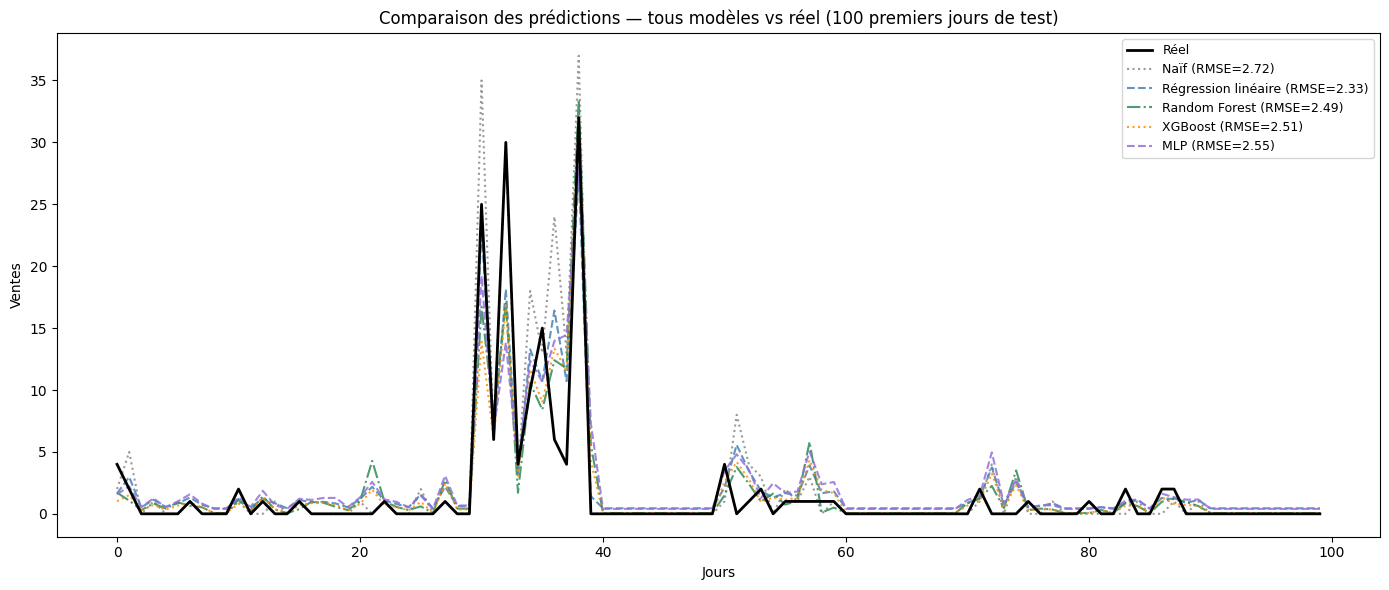

In [21]:
plt.figure(figsize=(14, 6))

n = 100  # nombre de points à afficher

plt.plot(y_test.values[:n], 
         label="Réel", 
         color="black", 
         linewidth=2, 
         zorder=5)

plt.plot(X_test["lag_1"].values[:n], 
         label=f"Naïf (RMSE={rmse_naif:.2f})", 
         color="grey", 
         linestyle="dotted", 
         alpha=0.8)

plt.plot(pred_rl[:n],  
         label=f"Régression linéaire (RMSE={rmse_rl:.2f})", 
         color="steelblue", 
         linestyle="--",
         alpha=0.85)

plt.plot(pred_rf[:n], 
         label=f"Random Forest (RMSE={rmse_rf:.2f})", 
         color="seagreen", 
         linestyle="-.",
         alpha=0.85)

plt.plot(pred_xgb[:n], 
         label=f"XGBoost (RMSE={rmse_xgb:.2f})", 
         color="darkorange", 
         linestyle=":",
         alpha=0.85)

plt.plot(pred_mlp[:n], 
         label=f"MLP (RMSE={rmse_mlp:.2f})", 
         color="mediumpurple", 
         linestyle="--",
         alpha=0.85)

plt.title("Comparaison des prédictions — tous modèles vs réel (100 premiers jours de test)")
plt.xlabel("Jours")
plt.ylabel("Ventes")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()